# Работа с файлами

Когда в программе используется файл, как правило требуется выполнить три шага:

* Открыть файл. В процессе открытия файла создается связь между файлом и программой. Открытие файла вывода обычно создает файл на диске и позволяет программе записать в него данные. Открытие файла ввода позволяет программе прочитать данные из файла.
* Обработать файл. На этом шаге данные либо записываются в файл (если это файл вывода), либо считываются из файла (если это файл ввода).
* Закрыть файл. После использования файла программой его нужно закрыть, тем самым освободить ресурс и разорвать связь файла с программой.

**Типы файлов**

Существует два типа файлов: текстовые и двоичные (бинарные).

**Текстовый файл** содержит данные, которые были закодированы в виде текста при помощи такой схемы кодирования, как ASCII или Юникод. Даже если файл содержит числа, эти числа в файле хранятся как набор символов. В результате файл можно открыть и просмотреть в текстовом редакторе, таком как Notepad.

**Двоичный файл** содержит данные, которые не были преобразованы в текст. Данные, которые помещены в двоичный файл, предназначены только для чтения программой, и такой файл невозможно просмотреть в текстовом редакторе.

✅ Разделение файлов на текстовые и бинарные искусственное, так как любой текстовый файл бинарен.

Python позволяет работать и с текстовыми, и с двоичными файлами, но в рамках этого курса мы будем работать только с текстовыми файлами.

**Методы доступа к файлам**

Большинство языков программирования обеспечивает два способа получения доступа к данным в файле:

* последовательный,
* прямой или произвольный.

Последовательный, как при проигрывании кассет с записью на пленке, выдает порции информации одну за другой. При работе с таким файлом не получится перескочить сразу к нужной части данных, сначала придется прочитать все предыдущие.

При работе с файлом с прямым или произвольным доступом можно перескочить непосредственно к любой порции данных, не читая предыдущие. Как проигрыватель компакт-дисков или МР3-плеер перескакивает сразу к любой песне.

**Кодировка файлов**



Кодировка UTF-8 самая распространенная, рекомендуем использовать именно ее в качестве кодировки по умолчанию для текстовых файлов.

UTF-8 — достаточно сложная кодировка, на обозначение одного символа в ней может использоваться от одного до шести байт.

В операционной системе Windows до сих пор используется однобайтовая кодировка Windows-1251. Чтобы избежать проблем при работе с текстовыми файлами в Windows нужно явно указывать кодировку.

При работе с ОС Linux и MacOS таких проблем не возникает, поскольку в них кодировка UTF-8 применяется по умолчанию.



# Работа с файлами в Google Colab

Если внешние файлы хранятся на локальном компьютере, то нам нужно подгрузить их в так называемое «Сессионное хранилище» (session storage, по сути, сервер Google).

Для начала откройте вкладку с файлами слева, а затем выберите значок загрузки файлов. Загруженный файл теперь будет отображаться во вкладке с файлами. Если же вы создадите новый файл через код, то он по-умолчанию будет расположен в этой же вкладке.

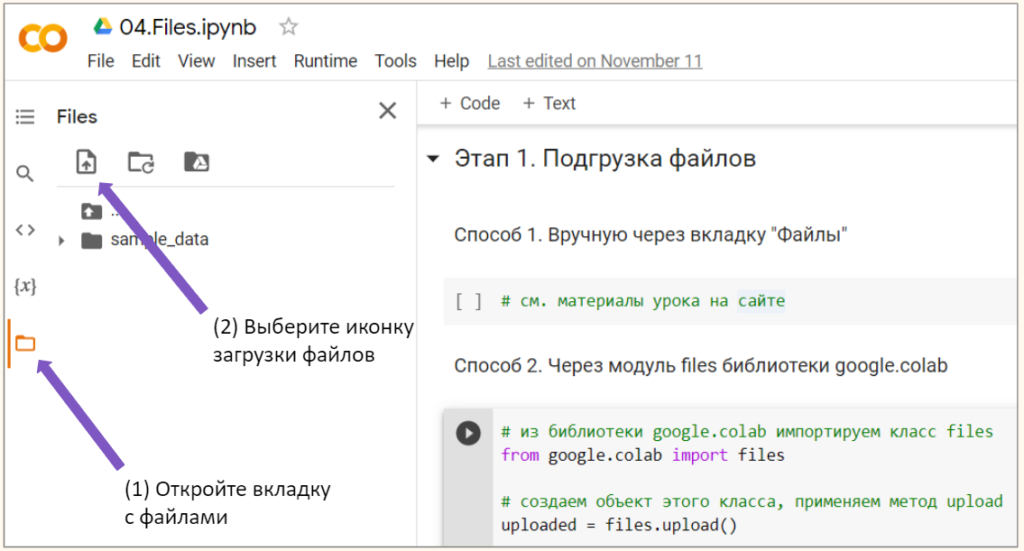

Чтобы считать данные из файлов на вашем Google Диске в Google Colab, выполните следующие шаги:
1. Монтирование вашего Google Диска:
Сначала установите соединение между вашим аккаунтом Google Диска и вашим Colab-ноутбуком. Для этого запустите следующий код:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


После выполнения этой команды вам будет предложено авторизоваться. Следуйте инструкциям на экране и введите предоставленный код авторизации.

2. Навигация к файлу, который вы хотите импортировать:

После успешного монтирования вашего Google Диска вы можете перейти к файлу, который хотите импортировать, используя панель навигации слева от вашего Colab-ноутбука. Кликнуть на иконку с папкой ("Файлы), далее drive - MyDrive - ... и далее до места хранения вашего файла на Google-диске. При наведении курсура на название нужного файла справа появляется меню (три точки), где одни из пунктов можно выбрать "Скопировать путь". Эти скопированные пути вы далее и используете при работе с данными.


# Работа с **txt** файлами в Python

Для открытия файлов в Python существует функция open(). Она создает файловый объект и связывает его с файлом на диске. Общий формат применения функции open():

In [ ]:
файловая_переменная = open(имя_файла, режим_доступа)

* файловая переменная – имя переменной, которая ссылается на файловый объект;
* имя_файла – строковый литерал, задающий имя файла;
* режим_доступа – строковый литерал, задающий режим доступа (чтение, запись, и т.д.), в котором файл будет открыт.

Ниже представлены строковые литералы (символы), используемые для задания режима доступа.

In [ ]:
'r'	Read (чтение)           # Открыть файл только для чтения. Такой файл не может быть изменен.
'w'	Write (запись)	        # Открыть файл для записи. Если файл уже существует, стереть его содержимое.
                            # Если файл не существует, он будет создан.
'a'	Append (добавление)	    # Открыть файл для записи. Данные будут добавлены в конец файла. Если файл не существует, он будет создан.
'r+'	Read + Write	    # Открыть файл для чтения и записи. В этом режиме происходит частичная перезапись содержимого файла.
'x'	Create (создание)	    # Создать новый файл. Если файл существует, произойдет ошибка.

Предположим, файл numbers.txt содержит данные, и мы хотим открыть его для чтения.

In [ ]:
some_file = open('/content/drive/MyDrive/numbers.txt', 'r')

В переменную some_file в примере выше не попадает содержимое файла numbers.txt. Фактически это ссылка на файл, ее еще называют **дескриптор файла**.

In [ ]:
some_file

<_io.TextIOWrapper name='/content/drive/MyDrive/numbers.txt' mode='r' encoding='UTF-8'>

Предположим, надо создать файл с именем sales.txt и записать в него данные о продажах. Это можно сделать с помощью строки кода:

In [ ]:
sales_file = open('sales.txt', 'w')

Если не указать место расположения файла, а только его название, то он появится в папке contens, но будет удалён, после завершения текущего сеанса в colab.

**Кодировка**

При работе с текстом на русском языке нужно указать кодировку, для этого служит параметр encoding:

In [ ]:
file = open('info.txt', 'r', encoding='utf-8')

Указание кодировки при открытии файла – хороший тон, лучше придерживаться этого правила.

Чтобы получить кодировку открытого файла, используют файловое свойство encoding.

In [ ]:
print(some_file.encoding)

UTF-8


**Закрытие файлов**

После окончания работы с файлом его необходимо закрыть. Для этого есть несколько причин:

* если файл изменялся, это позволит корректно его сохранить;
* если открытый файл потребуется другим программам, ваша программа может его блокировать;
* не стоит держать в памяти лишние, уже не нужные данные;
* удалить открытый кем-то файл проблематично.

Для закрытия файла используется файловый метод close():

In [ ]:
print(some_file.closed)
some_file.close()
print(some_file.closed)

False
True


✅ Так как Python — язык с автоматическим управлением памятью, все файлы закрываются автоматически после успешного завершения программы или когда удаляется последняя ссылка на файловый объект. Но важно все равно закрывать файл, как только он перестает быть нужным. Это помогает избегать конфликтов совместного доступа и риска получить испорченный файл, если программа завершится аварийно.

**Чтение содержимого файла**

При открытии файла с помощью функции open() в файловую переменную попадает не содержимое файла, а ссылка на файл (дескриптор файла).




In [ ]:
file = open('/content/drive/MyDrive/languages.txt', 'r')
file

<_io.TextIOWrapper name='/content/drive/MyDrive/languages.txt' mode='r' encoding='utf-8'>

Для чтения содержимого открытого для чтения файла используются три файловых метода:

* read() – читает все содержимое файла;
* readline() – читает одну строку из файла;
* readlines() – читает все содержимое файла и возвращает список строк.

**Метод read()**

Файловый метод read() считывает все содержимое из файла и возвращает строку, которая может содержать символы перехода на новую строку '\n'.

In [ ]:
content = file.read()

Если методу read() передать целочисленный параметр, то будет считано не более заданного количества символов. Например, считывать файл посимвольно можно при помощи метода read(1).

In [ ]:
some_char = file.read(2)
some_char

'Ja'

In [ ]:
file.close()

In [ ]:
some_char

**Метод readline()**

Файловый метод readline() считывает одну строку из файла (до символа конца строки '\n'), при этом возвращается считанная строка вместе с символом '\n'. Если считать строку не удалось – достигнут конец файла и больше строк в нем нет, возвращается пустая строка.

In [ ]:
file = open('/content/drive/MyDrive/languages.txt', 'r', encoding='utf-8')
language = file.readline()
print(language)
language = file.readline()
print(language)
language = file.readline()
print(language)
file.close()


Python

Java

Javascript



Прочитать содержимое всего файла построчно можно c помощью цикла for:

In [ ]:
file = open('/content/drive/MyDrive/languages.txt', 'r', encoding='utf-8')

for line in file:
    print(line.strip())

file.close()

Python
Java
Javascript
C#
C
C++
PHP
R
Objective-C


Метод readline() довольно удобен, когда мы хотим управлять процессом чтения из файла, особенно если файл очень большой и его полное считывание может привести к нехватке памяти.

**Метод readlines()**

Файловый метод readlines() считывает все строки из файла и возвращает список из всех считанных строк (одна строка — один элемент списка). При этом, каждая строка в списке заканчивается символом переноса строки  '\n'.

In [ ]:
file = open('/content/drive/MyDrive/languages.txt', 'r', encoding='utf-8')

languages = file.readlines()

file.close()

languages

['Python\n',
 'Java\n',
 'Javascript\n',
 'C#\n',
 'C\n',
 'C++\n',
 'PHP\n',
 'R\n',
 'Objective-C']

In [ ]:
file = open('/content/drive/MyDrive/languages.txt', 'r', encoding='utf-8')

languages = [line.strip() for line in file.readlines()] # Удаление переносов строк

file.close()

languages

['Python', 'Java', 'Javascript', 'C#', 'C', 'C++', 'PHP', 'R', 'Objective-C']

✅ Если передать в функцию list() ссылку на файловый объект list(file) , получим тот же результат, что при вызове метода file.readlines()

**Менеджер контекста**

Как уже сказано, важно своевременно закрывать файлы с помощью метода close(). Закрытие файлов вручную, а также отдача закрытия на откуп среде исполнения, обладают существенным недостатком: если между открытием файла и его закрытием произойдёт ошибка, в лучшем случае файл окажется открыт слишком долго, а в худшем случае часть данных не сохранится.

Хочется иметь возможность автоматически закрывать файл сразу после окончания работы с ним и осуществлять закрытие даже при возникновении ошибки. Файловые объекты уже умеют работать в таком режиме, но для этого их нужно использовать как менеджеры контекста.

Менеджер контекста — объект, реализующий одноименный протокол. Объекты, реализующие этот протокол, позволяют использовать следующий специальный синтаксис:

In [ ]:
with object as name:
    # Здесь нам доступен ресурс name.
    # Это тело with-блока.
# А здесь ресурс name уже освобождён, даже если в теле with-блока произошла ошибка.

Весь код в теле with-блока работает "в контексте". Чаще всего контекст подразумевает выделение некоего ресурса, например, файла. По выходу из контекста ресурс автоматически освобождается, даже если при выполнении блока возникло исключение.

Как только закончится код, оформленный с отступами в with (аналогичные отступы в циклах или функциях), это будет означать, что контекст закончился, и Python автоматически закроет файл.

In [ ]:
with open('/content/drive/MyDrive/languages.txt', 'r', encoding='utf-8') as file:
    for line in file.readlines():
        print(line.strip())
                          # автоматическое закрытие файла
print('Файл закрыт')

Python
Java
Javascript
C#
C
C++
PHP
R
Objective-C
Файл закрыт


**Обратите внимание:** при использовании менеджера контекста не требуется использовать метод close()

**Запись данных в файлы**

Для записи данных в файл он должен быть открыт для записи (режимы 'w', 'а', 'r+'), иначе произойдет ошибка.

Для записи используются два файловых метода:

* write() – записывает переданную строку в файл;
* writelines() – записывает переданный список строк в файл.



**write()**

Общий формат применения файлового метода write():

**файловая_переменная.writе(строковое_значение)**

Где:
* файловая переменная – это имя переменной, которая ссылается на файловый объект;
* строковое значение – это символьная последовательность, которая будет записана в файл.

Рассмотрим текcтовый файл myfile.txt, содержащий следующие строки:

In [ ]:
First line of the file.
Second line of the file.
Third line of the file.

Если файл открыт в режиме 'w', то его содержимое сначала полностью стирается, а уже затем в него добавляются данные.

После выполнения следующего кода:

In [ ]:
with open('myfile.txt', 'w', encoding='utf-8') as file:
    file.write('Python forever\n')
    file.write('We love python <3')

файл myfile.txt будет содержать:

In [ ]:
Python forever
We love python <3

Если файл открыт в режиме 'a', то запись происходит в самый конец файла.

После выполнения следующего кода:

In [ ]:
with open('myfile.txt', 'a', encoding='utf-8') as file:
    file.write('Python forever\n')
    file.write('We love python <3')

файл myfile.txt будет содержать:

In [ ]:
First line of the file.
Second line of the file.
Third line of the file.Python forever
We love python <3

Если файл открыт в режиме 'r+', то происходит частичная перезапись его содержимого.

После выполнения следующего кода:

In [ ]:
with open('myfile.txt', 'r+', encoding='utf-8') as file:
    file.write('Python forever\n')
    file.write('We love python.')

файл myfile.txt будет содержать:

In [ ]:
Python forever
We love python. file.
Third line of the file.

**Метод writelines()**

Последовательные вызовы метода write() дописывают текст в конец файла.

Приведенный ниже код создает файл philosophers.txt и записывает в него три строки текста:

In [ ]:
with open('philosophers.txt', 'w', encoding='utf-8') as file:
    file.write('Джoн Локк\n')
    file.write('Дэвид Хьюм\n')
    file.write('Эдмyнд Берк\n')

На практике часто приходится записывать в файл содержимое целого списка. Это можно сделать с помощью цикла или метода writelines(), что удобнее. Метод writelines() принимает в качестве аргумента список строк и записывает его в файл.

Приведенный ниже код создает файл philosophers.txt и записывает в него содержимое списка philosophers:

In [ ]:
philosophers = ['Джoн Локк\n', 'Дэвид Хьюм\n', 'Эдмyнд Берк\n']

with open('philosophers.txt', 'w', encoding='utf-8') as file:
    file.writelines(philosophers)

Обратите внимание, что все записанные в файл строковые значения оканчиваются символом '\n', экранированной последовательностью новой строки. Символ '\n' не только отделяет находящиеся в файле значения друг от друга, но и обеспечивает появление каждого из них на отдельной строке во время просмотра данных в текстовом редакторе.

Такой вариант записи предпочтителен, когда нужно записать большой объем текста, который вы получаете и обрабатываете строчка за строчкой. Можно предварительно накопить весь текст в одну большую строку, однако для этого может потребоваться большой объём памяти. Гораздо лучше записывать строчки по мере готовности и writelines для этого подходит идеально!

**Запись в файл с помощью функции print()**

Для записи данных в файл можно также использовать встроенную функцию print(). Для этого нужно передать ей еще один именованный аргумент file, указывающий на открытый файл. При этом функция print() автоматически добавляет переход на новую строку.

Приведенный ниже код:

In [ ]:
with open('philosophers.txt', 'w', encoding='utf-8') as output:
    print('Джoн Локк', file=output)
    print('Дэвид Хьюм', file=output)
    print('Эдмyнд Берк', file=output)

создает файл philosophers.txt с содержимым:

In [ ]:
Джoн Локк
Дэвид Хьюм
Эдмyнд Берк

# Формат CSV

CSV (от англ. Comma-Separated Values — значения, разделённые запятыми) — текстовый формат, предназначенный для представления табличных данных. Строка таблицы соответствует строке текста, которая содержит одно или несколько полей, разделенных запятыми.

Формат файла CSV поддерживается практически всеми электронными таблицами и системами управления базами данных, включая LibreOffice Calc, Gnumeric, Emacs, Microsoft Excel, Numbers, ТаблицаПро, CSVed, KSpread, Google Docs.

Импорт и экспорт CSV-файлов возможен во многих инженерных пакетах, например, ANSYS и LabVIEW.

Например, таблица


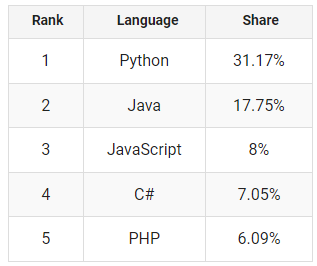

в формате csv будет выглядеть так:

In [ ]:
Rank,Language,Share
1,Python,31.17%
2,Java,17.75%
3,JavaScript,8%
4,C#,7.05%
5,PHP,6.09%

# Ручная работа с файлами

Рассмотрим текстовый файл products.csv, содержащий информацию о товарах некоторого интернет магазина. Файл содержит информацию о трех столбцах:

*  keywords (ключевые слова)
*  price (цена)
*  product_name (имя продукта)

и имеет следующее содержимое:

In [ ]:
keywords,price,product_name
Садовый стул,1699,ВЭДДО
Садовый стул,2999,ЭПЛАРО
Садовый табурет,1699,ЭПЛАРО
Садовый стол,1999,ТЭРНО
Складной стол,7499,ЭПЛАРО
Настил,1299,РУННЕН
Стеллаж,1299,ХИЛЛИС
Кружка,39,СТЕЛЬНА
Молочник,299,ВАРДАГЕН
Термос для еды,699,ЭФТЕРФРОГАД
Ситечко,59,ИДЕАЛИСК
Чайник заварочный,499,РИКЛИГ
Кофе-пресс,699,УПХЕТТА
Чашка с блюдцем,249,ИКЕА
Кружка,249,ЭМНТ
Ситечко,199,САККУННИГ
Кружка,199,ФИНСТИЛТ
Тарелка,269,ЭВЕРЕНС

Разделителем записей был выбран символ новой строки, а разделителем полей — символ запятой.

В результате мы получили текстовый файл, который легко читается и человеком и компьютерной программой.

Поскольку любой csv файл является текстовым, то нам не составит труда обработать его "руками", подобно тому, как мы обрабатываем обычный текстовый файл.

In [ ]:
with open('/content/drive/MyDrive/products.csv', encoding='utf-8') as file:
    data = file.read()
    for line in data.splitlines():
        print(line.split(','))

['keywords', 'price', 'product_name']
['Садовый стул', '1699', 'ВЭДДО']
['Садовый стул', '2999', 'ЭПЛАРО']
['Садовый табурет', '1699', 'ЭПЛАРО']
['Садовый стол', '1999', 'ТЭРНО']
['Складной стол', '7499', 'ЭПЛАРО']
['Настил', '1299', 'РУННЕН']
['Стеллаж', '1299', 'ХИЛЛИС']
['Кружка', '39', 'СТЕЛЬНА']
['Молочник', '299', 'ВАРДАГЕН']
['Термос для еды', '699', 'ЭФТЕРФРОГАД']
['Ситечко', '59', 'ИДЕАЛИСК']
['Чайник заварочный', '499', 'РИКЛИГ']
['Кофе-пресс', '699', 'УПХЕТТА']
['Чашка с блюдцем', '249', 'ИКЕА']
['Кружка', '249', 'ЭМНТ']
['Ситечко', '199', 'САККУННИГ']
['Кружка', '199', 'ФИНСТИЛТ']
['Тарелка', '269', 'ЭВЕРЕНС']


Для построчного разделения текста удобно использовать строковый метод splitlines(), вместо метода split('\n').

Мы также можем создать вложенный список (таблицу) для более удобного взаимодействия с данными. С помощью такой таблицы мы можем обратиться к цене седьмого по счету товара:

In [ ]:
with open('/content/drive/MyDrive/products.csv', encoding='utf-8') as file:
    data = file.read()
    table = [r.split(',') for r in data.splitlines()]
    print(table)
    print(table[7][1])

[['keywords', 'price', 'product_name'], ['Садовый стул', '1699', 'ВЭДДО'], ['Садовый стул', '2999', 'ЭПЛАРО'], ['Садовый табурет', '1699', 'ЭПЛАРО'], ['Садовый стол', '1999', 'ТЭРНО'], ['Складной стол', '7499', 'ЭПЛАРО'], ['Настил', '1299', 'РУННЕН'], ['Стеллаж', '1299', 'ХИЛЛИС'], ['Кружка', '39', 'СТЕЛЬНА'], ['Молочник', '299', 'ВАРДАГЕН'], ['Термос для еды', '699', 'ЭФТЕРФРОГАД'], ['Ситечко', '59', 'ИДЕАЛИСК'], ['Чайник заварочный', '499', 'РИКЛИГ'], ['Кофе-пресс', '699', 'УПХЕТТА'], ['Чашка с блюдцем', '249', 'ИКЕА'], ['Кружка', '249', 'ЭМНТ'], ['Ситечко', '199', 'САККУННИГ'], ['Кружка', '199', 'ФИНСТИЛТ'], ['Тарелка', '269', 'ЭВЕРЕНС']]
1299


Или мы можем также отсортировать товары по цене и напечатать 5 самых дешевых товаров.

In [ ]:
with open('/content/drive/MyDrive/products.csv', encoding='utf-8') as file:
    data = file.read()
    table = [r.split(',') for r in data.splitlines()]
    del table[0]                                        # удаляем заголовок
    table.sort(key=lambda item: int(item[1]))
    for line in table[:5]:
        print(line)

['Кружка', '39', 'СТЕЛЬНА']
['Ситечко', '59', 'ИДЕАЛИСК']
['Ситечко', '199', 'САККУННИГ']
['Кружка', '199', 'ФИНСТИЛТ']
['Чашка с блюдцем', '249', 'ИКЕА']


Обратите внимание на то, что мы удалили первый элемент из списка, так как он содержит не данные, а заголовки. Также стоит обратить внимание на то, что в лямбда-функции мы преобразуем элемент item[1] к числовому типу, иначе сортировка будет работать не так, как полагается.

В приведенном выше файле products.csv символ запятой использовался в качестве разделителя полей. Однако бывают ситуации, в которых сам символ запятой является легитимным символом. Например, столбец keywords может содержать (и как правило на практике содержит) несколько ключевых слов. В таком случае структура файла нарушается. Для решения такой проблемы можно использовать два подхода.

**1 подход.**
Если поле содержит запятые, то это поле должно быть заключено в двойные кавычки. Если этого не сделать, то данные невозможно будет корректно обработать.

Содержимое файла products.csv может иметь вид:

In [ ]:
keywords,price,product_name
"Садовый стул, стул для дачи",1699,ВЭДДО
Садовый стул,2999,ЭПЛАРО
Садовый табурет,1699,ЭПЛАРО
Садовый стол,1999,ТЭРНО
"Складной стол, обеденный стол",7499,ЭПЛАРО
Настил,1299,РУННЕН
Стеллаж,1299,ХИЛЛИС
"Кружка, сосуд, стакан с ручкой",39,СТЕЛЬНА
Молочник,299,ВАРДАГЕН
Термос для еды,699,ЭФТЕРФРОГАД
Ситечко,59,ИДЕАЛИСК
Чайник заварочный,499,РИКЛИГ
Кофе-пресс,699,УПХЕТТА
Чашка с блюдцем,249,ИКЕА
"Кружка, стакан с ручкой",249,ЭМНТ
Ситечко,199,САККУННИГ
Кружка,199,ФИНСТИЛТ
"Тарелка, блюдце",269,ЭВЕРЕНС

Обратите внимание на записи с номерами 1, 5, 8, 15 и 18. В этих записях в столбце keywords используется символ запятой, и для правильной обработки данных нам необходимо соответствующее поле обрамить символом двойных кавычек.

Обратите внимание на то, что при таком содержимом файла products.csv наш код, написанный выше, является нерабочим, так как он разделит каждую строку через символ запятой.

**2 подход.** Использовать в качестве разделителя другой символ, например, символ табуляции (\t), который весьма редко встречается в качестве валидного содержимого файла.

In [ ]:
keywords	price	product_name
Садовый стул, стул для дачи	1699	ВЭДДО
Садовый стул	2999	ЭПЛАРО
Садовый табурет	1699	ЭПЛАРО
Садовый стол	1999	ТЭРНО
Складной стол, обеденный стол	7499	ЭПЛАРО
Настил	1299	РУННЕН
Стеллаж	1299	ХИЛЛИС
Кружка, сосуд, стакан с ручкой	39	СТЕЛЬНА
Молочник	299	ВАРДАГЕН
Термос для еды	699	ЭФТЕРФРОГАД
Ситечко	59	ИДЕАЛИСК
Чайник заварочный	499	РИКЛИГ
Кофе-пресс	699	УПХЕТТА
Чашка с блюдцем	249	ИКЕА
Кружка, стакан с ручкой	249	ЭМНТ
Ситечко	199	САККУННИГ
Кружка	199	ФИНСТИЛТ
Тарелка, блюдце	269	ЭВЕРЕНС

Формат данных csv, в котором разделителем является символ табуляции, называют tsv (англ. tab separated values — «значения, разделенные табуляцией»).

tsv — текстовый формат для представления табличных данных. Каждая запись в таблице — строка текстового файла. Каждое поле записи отделяется от других символом табуляции, а точнее — горизонтальной табуляции.

tsv и csv — формы более общего формата dsv (англ. delimiter separated values — «значения, разграниченные разделителем»).

Приведенный ниже код правильно обрабатывает файл products_tab.tsv, в котором символом разделителя выбран символ табуляции (\t) и выводит
5 самых дешевых товаров:

In [ ]:
with open('/content/drive/MyDrive/products_tab.csv', encoding='utf-8') as file:
    data = file.read()
    table = [r.split('\t') for r in data.splitlines()]
    del table[0]
    table.sort(key=lambda item: int(item[1]))
    for line in table[:5]:
        print(line)

['Кружка, сосуд, стакан с ручкой', '39', 'СТЕЛЬНА']
['Ситечко', '59', 'ИДЕАЛИСК']
['Ситечко', '199', 'САККУННИГ']
['Кружка', '199', 'ФИНСТИЛТ']
['Чашка с блюдцем', '249', 'ИКЕА']


# Модуль csv

Несмотря на то что csv формат очень прост и мы можем работать с ним, как с обычным текстовым файлом, на практике используется встроенный модуль csv.

В данном модуле есть два основных объекта: reader и writer, созданные, чтобы читать и создавать csv файлы соответственно.

# Чтение данных с помощью reader

Для импорта модуля мы используем строку кода:

In [ ]:
import csv

Этот модуль входит в стандартную библиотеку, и его не нужно устанавливать каким‑то особенным способом.

Рассмотрим все тот же файл products.csv, содержащий информацию о товарах интернет магазина.

In [ ]:
keywords,price,product_name
Садовый стул,1699,ВЭДДО
Садовый стул,2999,ЭПЛАРО
Садовый табурет,1699,ЭПЛАРО
Садовый стол,1999,ТЭРНО
Складной стол,7499,ЭПЛАРО
Настил,1299,РУННЕН
Стеллаж,1299,ХИЛЛИС
Кружка,39,СТЕЛЬНА
Молочник,299,ВАРДАГЕН
Термос для еды,699,ЭФТЕРФРОГАД
Ситечко,59,ИДЕАЛИСК
Чайник заварочный,499,РИКЛИГ
Кофе-пресс,699,УПХЕТТА
Чашка с блюдцем,249,ИКЕА
Кружка,249,ЭМНТ
Ситечко,199,САККУННИГ
Кружка,199,ФИНСТИЛТ
Тарелка,269,ЭВЕРЕНС

Приведенный ниже код читает содержимое файла products.csv и выводит его:



In [ ]:
import csv

with open('/content/drive/MyDrive/products.csv', encoding='utf-8') as file:
    rows = csv.reader(file)                               # создаем reader объект
    for row in rows:
        print(row)

['keywords', 'price', 'product_name']
['Садовый стул', '1699', 'ВЭДДО']
['Садовый стул', '2999', 'ЭПЛАРО']
['Садовый табурет', '1699', 'ЭПЛАРО']
['Садовый стол', '1999', 'ТЭРНО']
['Складной стол', '7499', 'ЭПЛАРО']
['Настил', '1299', 'РУННЕН']
['Стеллаж', '1299', 'ХИЛЛИС']
['Кружка', '39', 'СТЕЛЬНА']
['Молочник', '299', 'ВАРДАГЕН']
['Термос для еды', '699', 'ЭФТЕРФРОГАД']
['Ситечко', '59', 'ИДЕАЛИСК']
['Чайник заварочный', '499', 'РИКЛИГ']
['Кофе-пресс', '699', 'УПХЕТТА']
['Чашка с блюдцем', '249', 'ИКЕА']
['Кружка', '249', 'ЭМНТ']
['Ситечко', '199', 'САККУННИГ']
['Кружка', '199', 'ФИНСТИЛТ']
['Тарелка', '269', 'ЭВЕРЕНС']


Самая важная строка кода в программе — это строка с созданием reader объекта.

Объект reader дает доступ к построчному итератору, полностью аналогичному работе с файлом или списком.

После выполнения этой строки в переменную rows будет записан итератор, с помощью которого можно «пробежаться» циклом по файлу. В каждой итерации цикла при этом будет доступна соответствующая строка файла, уже разбитая по запятым и представляющая собой список. При этом автоматически будут учтены все нюансы с запятыми внутри кавычек и самими кавычками.

Так как каждая строка файла, полученная из итератора, является списком, к ней можно применять все способы работы со списками.

Приведенный ниже код использует распаковку списка и выводит:

In [ ]:
import csv

with open('/content/drive/MyDrive/products.csv', encoding='utf-8') as file:
    rows = csv.reader(file)
    for keywords, price, product_name in rows:
        print(f'Ключевые слова: {keywords}, цена: {price}, название: {product_name}')

Ключевые слова: keywords, цена: price, название: product_name
Ключевые слова: Садовый стул, цена: 1699, название: ВЭДДО
Ключевые слова: Садовый стул, цена: 2999, название: ЭПЛАРО
Ключевые слова: Садовый табурет, цена: 1699, название: ЭПЛАРО
Ключевые слова: Садовый стол, цена: 1999, название: ТЭРНО
Ключевые слова: Складной стол, цена: 7499, название: ЭПЛАРО
Ключевые слова: Настил, цена: 1299, название: РУННЕН
Ключевые слова: Стеллаж, цена: 1299, название: ХИЛЛИС
Ключевые слова: Кружка, цена: 39, название: СТЕЛЬНА
Ключевые слова: Молочник, цена: 299, название: ВАРДАГЕН
Ключевые слова: Термос для еды, цена: 699, название: ЭФТЕРФРОГАД
Ключевые слова: Ситечко, цена: 59, название: ИДЕАЛИСК
Ключевые слова: Чайник заварочный, цена: 499, название: РИКЛИГ
Ключевые слова: Кофе-пресс, цена: 699, название: УПХЕТТА
Ключевые слова: Чашка с блюдцем, цена: 249, название: ИКЕА
Ключевые слова: Кружка, цена: 249, название: ЭМНТ
Ключевые слова: Ситечко, цена: 199, название: САККУННИГ
Ключевые слова: Кружка

При создании reader объекта мы можем его настраивать, указывая:

*  аргумент delimiter — односимвольная строка, используемая для разделения полей, по умолчанию имеет значение ','
*  аргумент quotechar — односимвольная строка, используемая для кавычек в полях, содержащих специальные символы, по умолчанию имеет значение ' " '.

Пусть содержимое файла products_semicolon.csv имеет вид (в качестве разделителя выбран символ ';'):

In [ ]:
keywords;price;product_name
"Садовый стул, стул для дачи";1699;ВЭДДО
Садовый стул;2999;ЭПЛАРО
Садовый табурет;1699;ЭПЛАРО
Садовый стол;1999;ТЭРНО
"Складной стол, обеденный стол";7499;ЭПЛАРО
Настил;1299;РУННЕН
Стеллаж;1299;ХИЛЛИС
"Кружка, сосуд, стакан с ручкой";39;СТЕЛЬНА
Молочник;299;ВАРДАГЕН
Термос для еды;699;ЭФТЕРФРОГАД
Ситечко;59;ИДЕАЛИСК
Чайник заварочный;499;РИКЛИГ
Кофе-пресс;699;УПХЕТТА
Чашка с блюдцем;249;ИКЕА
"Кружка, стакан с ручкой";249;ЭМНТ
Ситечко;199;САККУННИГ
Кружка;199;ФИНСТИЛТ
"Тарелка, блюдце";269;ЭВЕРЕНС

Приведенный ниже код выводит первые 6 строк файла, включая заголовок с названиями столбцов:

In [ ]:
import csv

with open('/content/drive/MyDrive/products_semicolon.csv', encoding='utf-8') as file:
    rows = csv.reader(file, delimiter=';', quotechar='"')
    for index, row in enumerate(rows):
        if index > 5:
            break
        print(row)

['keywords', 'price', 'product_name']
['Садовый стул, стул для дачи', '1699', 'ВЭДДО']
['Садовый стул', '2999', 'ЭПЛАРО']
['Садовый табурет', '1699', 'ЭПЛАРО']
['Садовый стол', '1999', 'ТЭРНО']
['Складной стол, обеденный стол', '7499', 'ЭПЛАРО']


При создании reader объекта мы указываем, что символ-разделитель записей delimiter в нашем файле — точка с запятой, а символ кавычек quotechar — двойные кавычки. Кроме того, мы используем встроенную функцию enumerate() для нумерации строк.

Обратите внимание на то, что для корректной обработки данных мы должны все еще исключить первую строку из обработки, которая содержит названия столбцов.

# Чтение данных с помощью DictReader

Иcпользовать reader объект не всегда удобно, так как он возвращает сырые списки из строк файла, к тому же первой строкой является строка с названиями столбцов, которая практически всегда удаляется, так как мешает правильной обработке данных.

В модуле csv есть специальный объект DictReader, который поддерживает создание объекта-словаря на основе названий столбцов. С помощью DictReader объекта мы можем обращаться к полям не по индексу, а по названию, что делает код более понятным.

Пусть содержимое файла products_semicolon.csv имеет вид (в качестве разделителя выбран символ ';'):

In [ ]:
keywords;price;product_name
"Садовый стул, стул для дачи";1699;ВЭДДО
Садовый стул;2999;ЭПЛАРО
Садовый табурет;1699;ЭПЛАРО
Садовый стол;1999;ТЭРНО
"Складной стол, обеденный стол";7499;ЭПЛАРО
Настил;1299;РУННЕН
Стеллаж;1299;ХИЛЛИС
"Кружка, сосуд, стакан с ручкой";39;СТЕЛЬНА
Молочник;299;ВАРДАГЕН
Термос для еды;699;ЭФТЕРФРОГАД
Ситечко;59;ИДЕАЛИСК
Чайник заварочный;499;РИКЛИГ
Кофе-пресс;699;УПХЕТТА
Чашка с блюдцем;249;ИКЕА
"Кружка, стакан с ручкой";249;ЭМНТ
Ситечко;199;САККУННИГ
Кружка;199;ФИНСТИЛТ
"Тарелка, блюдце";269;ЭВЕРЕНС

Приведенный ниже код выводит:

In [ ]:
import csv

with open('/content/drive/MyDrive/products_semicolon.csv', encoding='utf-8') as file:
    rows = csv.DictReader(file, delimiter=';', quotechar='"')
    for row in rows:
        print(row)

{'keywords': 'Садовый стул, стул для дачи', 'price': '1699', 'product_name': 'ВЭДДО'}
{'keywords': 'Садовый стул', 'price': '2999', 'product_name': 'ЭПЛАРО'}
{'keywords': 'Садовый табурет', 'price': '1699', 'product_name': 'ЭПЛАРО'}
{'keywords': 'Садовый стол', 'price': '1999', 'product_name': 'ТЭРНО'}
{'keywords': 'Складной стол, обеденный стол', 'price': '7499', 'product_name': 'ЭПЛАРО'}
{'keywords': 'Настил', 'price': '1299', 'product_name': 'РУННЕН'}
{'keywords': 'Стеллаж', 'price': '1299', 'product_name': 'ХИЛЛИС'}
{'keywords': 'Кружка, сосуд, стакан с ручкой', 'price': '39', 'product_name': 'СТЕЛЬНА'}
{'keywords': 'Молочник', 'price': '299', 'product_name': 'ВАРДАГЕН'}
{'keywords': 'Термос для еды', 'price': '699', 'product_name': 'ЭФТЕРФРОГАД'}
{'keywords': 'Ситечко', 'price': '59', 'product_name': 'ИДЕАЛИСК'}
{'keywords': 'Чайник заварочный', 'price': '499', 'product_name': 'РИКЛИГ'}
{'keywords': 'Кофе-пресс', 'price': '699', 'product_name': 'УПХЕТТА'}
{'keywords': 'Чашка с блю

Обратите внимание на то, что переменная row имеет тип dict.

А приведенный ниже код выводит 5 самых дорогих товаров:

In [ ]:
import csv

with open('/content/drive/MyDrive/products_semicolon.csv', encoding='utf-8') as file:
    rows = csv.DictReader(file, delimiter=';', quotechar='"')
    expensive = sorted(rows, key=lambda item: int(item['price']), reverse=True)
    for record in expensive[:5]:
        print(record)

{'keywords': 'Складной стол, обеденный стол', 'price': '7499', 'product_name': 'ЭПЛАРО'}
{'keywords': 'Садовый стул', 'price': '2999', 'product_name': 'ЭПЛАРО'}
{'keywords': 'Садовый стол', 'price': '1999', 'product_name': 'ТЭРНО'}
{'keywords': 'Садовый стул, стул для дачи', 'price': '1699', 'product_name': 'ВЭДДО'}
{'keywords': 'Садовый табурет', 'price': '1699', 'product_name': 'ЭПЛАРО'}


При создании DictReader объекта значениями по умолчанию для аргументов delimiter и quotechar являются ',' (символ запятой) и '"' (символ двойной кавычки) соответственно.

# Запись данных с помощью writer

Для записи данных в csv файл можно использовать специальный writer объект.

Приведенный ниже код создает файл students.csv с содержимым:

In [ ]:
import csv

columns = ['first_name', 'second_name', 'class_number', 'class_letter']
data = [['Иван', 'Иванов', 11, 'А'], ['Петр', 'Петров', 9, 'Б'], ['Борис', 'Борисов', 10, 'В']]

with open('students.csv', 'w', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(columns)                 # запись заголовков
    for row in data:                         # запись строк
        writer.writerow(row)

In [ ]:
first_name,second_name,class_number,class_letter
Иван,Иванов,11,А
Петр,Петров,9,Б
Борис,Борисов,10,В

**Запись данных с помощью DictWriter**

Для записи данных в csv файл также можно использовать DictWriter объект, который позволяет записывать содержимое словаря в файл.

Приведенный ниже код создает файл students.csv с содержимым:

In [ ]:
import csv

data = [{'first_name': 'Иван', 'second_name': 'Иванов', 'class_number': 11, 'class_letter': 'А'},
        {'first_name': 'Петр', 'second_name': 'Петров', 'class_number': 9, 'class_letter': 'Б'},
        {'first_name': 'Борис', 'second_name': 'Борисов', 'class_number': 10, 'class_letter': 'В'}]

columns = ['first_name', 'second_name', 'class_number', 'class_letter']

with open('students.csv', 'w', encoding='utf-8', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=columns, delimiter=';')
    writer.writeheader()                 # запись заголовков
    for row in data:                     # запись строк
        writer.writerow(row)

In [ ]:
first_name;second_name;class_number;class_letter
Иван;Иванов;11;А
Петр;Петров;9;Б
Борис;Борисов;10;В

Обратите внимание на то, что ключи словарей, которые записываются в файл, должны совпадать с названиями полей, которые переданы в качестве аргумента fieldnames, иначе будет возникать ошибка ValueError.

**Примечание** Так как reader объект является итератором, мы можем преобразовать его в список или кортеж с помощью встроенных функций list() и tuple() соответственно, но не можем преобразовать в множество, т.к. его элементами могут быть только неизменяемые объекты, которыми списки не являются.

# Файлы json

JSON (англ. JavaScript Object Notation) — текстовый формат обмена данными, основанный на языке программирования JavaScript. Как и многие другие текстовые форматы, JSON легко читается людьми. Несмотря на происхождение от JavaScript, формат считается независимым от языка и может использоваться практически с любым языком программирования.

За счёт своей лаконичности формат JSON отлично подходит для сериализации сложных структур.

**Основные сферы применения:**

1. Веб-разработка и API - это "родная" и основная среда для JSON.
2. Данные и NoSQL базы данных. Документоориентированные базы данных (MongoDB, CouchDB) используют JSON-подобные форматы (BSON) для хранения записей. Это позволяет гибко хранить данные без жёсткой схемы, в отличие от таблиц в реляционных базах данных.
3. Конфигурационные файлы. Очень многие программы, фреймворки и инструменты используют JSON-файлы для хранения своих настроек.
4. Логи и мониторинг. Приложения и серверы могут записывать логи своей работы в формате JSON. Это удобно, потому что такие логи легко парсить и анализировать автоматизированными системами.

**Почему JSON популярен?**
* Человекочитаемый
* Легко парсится (разбирается) и генерируется
* Поддерживается практически всеми современными языками (JavaScript, Python, Java, C#, PHP, Go и т.д.)
* У него минимальный синтаксис, что делает файлы компактными (по сравнению, например, с XML).

**Синтаксис json формата**

В отличие от формата csv, данные в формате json не просто разделены запятыми, а чаще всего имеют структуру ключ-значение. Это напоминает словарь Python, но в отличие от словаря, ключи в json могут быть только строками, заключенными в двойные кавычки:

In [ ]:
{
   "firstName": "Иван",
   "lastName": "Гусев",
   "gender": "мужской"
}

Значениями в json формате могут быть не только строки. Это могут быть числа, списки значений, литералы true/false/null, а также вложенные объекты:

In [ ]:
{
   "firstName": "Иван",
   "lastName": "Гусев",
   "age": 29,
   "gender": "мужской",
   "smoke": false,
   "address": {
       "streetAddress": "Часовая 25, кв. 127",
       "city": "Москва",
       "postalCode": 125315
   },
   "phoneNumbers": ["+7 (919) 424-84-34", "+7 (916) 928-92-34"]
}

Списки значений, как видно из примера, напоминают списки Python. Они ограничены квадратными скобками, а значения списка указываются через запятую.

Вложенность данных может быть бесконечной. То есть значением ключа может быть список, а элементом этого списка — объект и т.д.

Обратите внимание на то, что переносы строк и отступы в формате json необязательны. Они нужны только для удобства чтения. Таким образом, с точки зрения формата json следующие данные эквивалентны:

In [ ]:
{
   "firstName": "Иван",
   "lastName": "Гусев",
   "gender": "мужской"
}

In [ ]:
{"firstName": "Иван", "lastName": "Гусев", "gender": "мужской"}

Обратите внимание, в формате JSON используются **только двойные кавычки.**

Итак, в качестве значений в JSON могут быть использованы:

* число (целое или вещественное)
* литералы true (истина), false (ложь), null (отсутствие значения)
* строка (последовательность символов, заключенная в двойные кавычки)
* список (заключается в квадратные скобки [ ], значения разделяются запятыми). Список может быть пустым, значения в пределах одного списка могут иметь разный тип
* вложенный объект (неупорядоченное множество пар ключ: значение, заключённое в фигурные скобки { }). Ключ описывается строкой, между ним и значением стоит символ :. Пары ключ-значение отделяются друг от друга запятыми.

# Модуль json

Преобразование переменных программы (Python-объектов) в формат для хранения называется сериализацией, а обратное преобразование — десериализацией. В Python для сериализации и десериализации в формат json есть модуль, который так и называется — json.

Для сериализации данных в json строку используется **функция dumps()** из модуля json. Для того, чтобы сериализовать данные с ее помощью, достаточно передать в нее аргументом любой сериализуемый Python объект. Так как json — текстовый формат, то сериализация в него — это по сути преобразование данных в строку.

In [1]:
import json

data = {'name': 'Russia', 'phone_code': 7, 'capital': 'Moscow', 'currency': 'RUB'}

json_data = json.dumps(data)            # сериализуем словарь data в json-строку

print(type(json_data))
print(json_data)

<class 'str'>
{"name": "Russia", "phone_code": 7, "capital": "Moscow", "currency": "RUB"}


Обратите внимание на кавычки, независимо от того, что в Python-словаре мы использовали одинарные, в результирующую строку всегда попадают двойные.

В отличие от функции dumps(), которая преобразует (сериализует) Python объект в json-строку, функция dump() записывает переданный Python объект в файл.

In [2]:
import json

data = {'name': 'Russia', 'phone_code': 7, 'capital': 'Moscow', 'currency': 'RUB'}

with open('countries.json', 'w') as file:
    json.dump(data, file)

**Необязательные аргументы indent, sort_keys и separators**



Аргумент indent задает отступ от левого края. По умолчанию имеет значение None для более компактного представления без отступов.

In [5]:
import json

data = {'name': 'Russia', 'phone_code': 7, 'capital': 'Moscow', 'currency': 'RUB'}

json_data1 = json.dumps(data, indent=2)
json_data2 = json.dumps(data, indent=10)

print(json_data1)
print(json_data2)

{
  "name": "Russia",
  "phone_code": 7,
  "capital": "Moscow",
  "currency": "RUB"
}
{
          "name": "Russia",
          "phone_code": 7,
          "capital": "Moscow",
          "currency": "RUB"
}


Аргумент sort_keys задает сортировку ключей в результирующем json. По умолчанию имеет значение False для более быстрого создания json. Если установить значение аргумента в True, то ключи будут отсортированы в алфавитном порядке, что особенно удобно, когда ключей много.

In [ ]:
import json

data = {'name': 'Russia', 'phone_code': 7, 'capital': 'Moscow', 'currency': 'RUB'}

json_data1 = json.dumps(data, indent=3)
json_data2 = json.dumps(data, indent=3, sort_keys=True)

print(json_data1)
print(json_data2)

{
   "name": "Russia",
   "phone_code": 7,
   "capital": "Moscow",
   "currency": "RUB"
}
{
   "capital": "Moscow",
   "currency": "RUB",
   "name": "Russia",
   "phone_code": 7
}


Аргумент separators задает кортеж, состоящий из двух элементов (item_separator, key_separator), которые представляют разделители для элементов и ключей.  По умолчанию аргумент имеет значение (', ', ': ').

In [6]:
import json

data = {'name': 'Russia', 'phone_code': 7, 'capital': 'Moscow', 'currency': 'RUB'}

json_data = json.dumps(data, indent=3, separators=(';', ' = '))

print(json_data)

{
   "name" = "Russia";
   "phone_code" = 7;
   "capital" = "Moscow";
   "currency" = "RUB"
}


Для десериализации данных нужно использовать **функцию loads()**. Ее аргумент — это строка с данными в формате json.



In [7]:
import json

json_data = '{"name": "Russia", "phone_code": 7, "capital": "Moscow", "currency": "RUB"}'

data = json.loads(json_data)
print(type(data))
print(data)

<class 'dict'>
{'name': 'Russia', 'phone_code': 7, 'capital': 'Moscow', 'currency': 'RUB'}


Как видно из примера, функция loads() десериализует json-строку в словарь.

В случае если строка для десериализации содержит данные с ошибкой, то модуль json не сможет правильно прочитать такую строку, и программа завершится с ошибкой.

Приведенный ниже код (запятая стоит после двоеточия) приводит к возникновению ошибки (исключения):

In [8]:
import json

json_data = '{"name":, "Russia", "phone_code": 7, "capital": "Moscow", "currency": "RUB"}'  # строка

data = json.loads(json_data)
print(type(data))
print(data)

JSONDecodeError: Expecting value: line 1 column 9 (char 8)

В отличие от функции loads(), которая в качестве аргумента принимает строку с данными в формате json, **функция load()** принимает файловый объект и возвращает его десериализованное содержимое.

Если файл data.json имеет следующее содержимое:

In [ ]:
{
  "name": "Russia",
  "phone_code": 7,
  "capital": "Moscow",
  "cities": ["Abakan", "Almetyevsk", "Anadyr", "Anapa", "Arkhangelsk", "Astrakhan"],
  "currency": "RUB"
}

То приведенный ниже код читает содержимое файла data.json в словарь data и выводит его содержимое:

In [ ]:
import json

with open('data.json') as file:
    data = json.load(file)                # передаем файловый объект
    for key, value in data.items():
        if type(value) == list:
            print(f'{key}: {", ".join(value)}')
        else:
            print(f'{key}: {value}')

In [ ]:
name: Russia
phone_code: 7
capital: Moscow
cities: Abakan, Almetyevsk, Anadyr, Anapa, Arkhangelsk, Astrakhan
currency: RUB

**Типы данных в json**



In [9]:
import json

json_data = '''
{
   "name": "Russia",
   "phone_code": 7,
   "latitude": 60.0,
   "capital": "Moscow",
   "timezones": ["Anadyr", "Barnaul", "Moscow", "Kirov"],
   "translations": {
      "nl": "Rusland",
      "hr": "Rusija",
      "de": "Russland",
      "es": "Rusia",
      "fr": "Russie",
      "it": "Russia"
   }
}'''

data = json.loads(json_data)

print(type(data['name']))
print(type(data['phone_code']))
print(type(data['latitude']))
print(type(data['timezones']))
print(type(data['translations']))

<class 'str'>
<class 'int'>
<class 'float'>
<class 'list'>
<class 'dict'>


Таким образом модуль json автоматически определяет тип значения при десериализации. Такая автоматическая работа с типами данных выгодно отличает json от csv, при работе с которым таких автоматических преобразований нет.

**Изменение типа данных**

Еще один важный аспект преобразования данных в формат JSON: данные не всегда будут того же типа, что исходные данные в Python. Например, кортежи при записи в JSON превращаются в списки.

In [14]:
import json

data = {
        (1,): 'Russia',
        'phone_code': 7,
        'latitude': 60.0,
        'capital': 'Moscow',
        'timezones': ('Anadyr', 'Barnaul', 'Moscow', 'Kirov')
       }

json_data = json.dumps(data)        # преобразуем dict в json
print(json_data)
new_data = json.loads(json_data)    # преобразуем json в dict
print(new_data)
print(data == new_data)

print(type(new_data['name']))
print(type(new_data['phone_code']))
print(type(new_data['latitude']))
print(type(new_data['timezones']))

TypeError: keys must be str, int, float, bool or None, not tuple

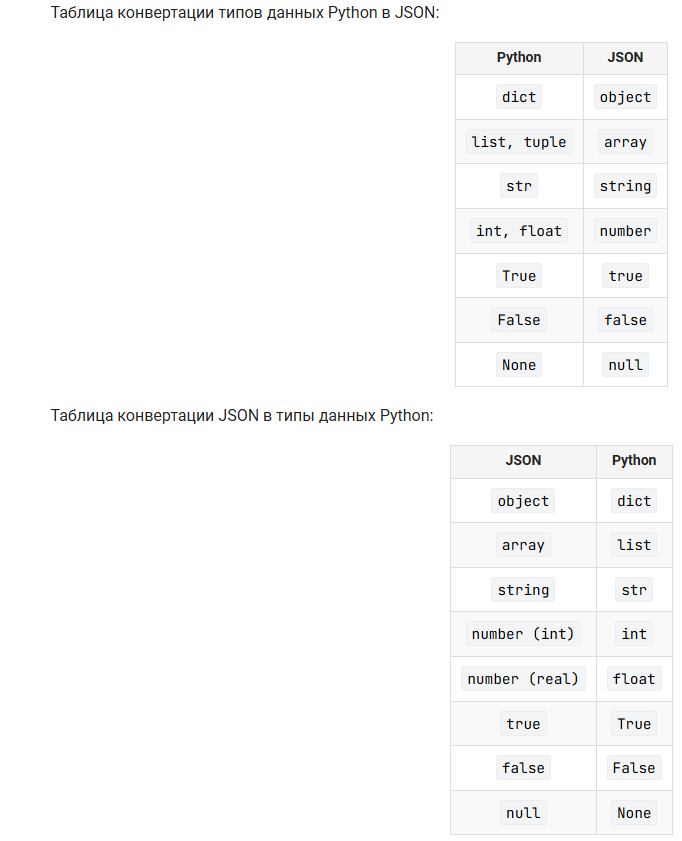

**Ограничение по типам данных**

В JSON ключами словаря могут быть только строки. Но, если в словаре Python использовались числа, булевы значения или None, то ошибки не будет, вместо этого они будут преобразованы в строки.

In [ ]:
import json

data = {1: 'Ivan', False: 'Anton', None: 'Ruslan'}
json_data = json.dumps(data)

print(json_data)

new_data = json.loads(json_data)    # преобразуем json в dict
print(new_data)

{"1": "Ivan", "false": "Anton", "null": "Ruslan"}
{'1': 'Ivan', 'false': 'Anton', 'null': 'Ruslan'}


В формат JSON нельзя записать словарь, у которого ключи – кортежи.

In [ ]:
import json

data = {
        'beegeek': 2018,
        ('Timur', 'Guev'): 29,
        ('Arthur', 'Kharisov'): 20,
        'stepik': 2013
       }

json_data = json.dumps(data)        # преобразуем dict в json

print(json_data)

TypeError: keys must be str, int, float, bool or None, not tuple

**Кириллические символы в json**



In [15]:
import json

data = {'firstName': 'Иван', 'lastName': 'Гусев'}
s = json.dumps(data)
print(s)

{"firstName": "\u0418\u0432\u0430\u043d", "lastName": "\u0413\u0443\u0441\u0435\u0432"}


Результат, скорее всего, будет неожиданным. Каждая буква из строк Иван и Гусев будет заменена на ее код. Эти коды стандартны, и код для каждой из букв индивидуален.

Обратное преобразование из строки в словарь вернет закодированное значение в первоначальный вид.

In [16]:
import json

data = {'firstName': 'Иван', 'lastName': 'Гусев'}
s = json.dumps(data)
print(s)
result = json.loads(s)
print(result)

{"firstName": "\u0418\u0432\u0430\u043d", "lastName": "\u0413\u0443\u0441\u0435\u0432"}
{'firstName': 'Иван', 'lastName': 'Гусев'}


Благодаря стандартным кодам, символы будут прочитаны и преобразованы в нужный вид любой программой на любом языке программирования.

С помощью необязательного аргумента ensure_ascii функций dumps() и dump() можно отказаться от такого кодирования.

In [17]:
import json

data = {'firstName': 'Иван', 'lastName': 'Гусев'}
s = json.dumps(data, ensure_ascii=False)
print(s)
result = json.loads(s)
print(result)

{"firstName": "Иван", "lastName": "Гусев"}
{'firstName': 'Иван', 'lastName': 'Гусев'}
